In [165]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [166]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, f1_score
from nba_api.stats.endpoints import leaguedashplayerstats
import matplotlib.pyplot as plt
import seaborn as sns



In [167]:

seasons = ['2020-21', '2021-22', '2022-23', '2023-24', '2024-25', '2025-26']

all_dfs = []

print("Fetching data from NBA API...")

for season in seasons:
    print(f"Fetching season {season}...")
    
    # Fetch player statistics for the current season in the loop
    api_call = leaguedashplayerstats.LeagueDashPlayerStats(
        season=season,
        season_type_all_star='Regular Season'
    )
    
    df_season = api_call.get_data_frames()[0]
    
    # Add a column so you know which season each row belongs to
    df_season['SEASON'] = season
    
    all_dfs.append(df_season)
    

# Combine all seasons into a single DataFrame
df_raw = pd.concat(all_dfs, ignore_index=True)

print("Finished fetching all seasons!")
print(df_raw.head())

Fetching data from NBA API...
Fetching season 2020-21...
Fetching season 2021-22...
Fetching season 2022-23...
Fetching season 2023-24...
Fetching season 2024-25...
Fetching season 2025-26...
Finished fetching all seasons!
   PLAYER_ID    PLAYER_NAME NICKNAME     TEAM_ID TEAM_ABBREVIATION   AGE  GP  \
0     203932   Aaron Gordon    Aaron  1610612743               DEN  25.0  50   
1    1628988  Aaron Holiday    Aaron  1610612754               IND  24.0  66   
2    1630174  Aaron Nesmith    Aaron  1610612738               BOS  21.0  46   
3    1627846    Abdel Nader    Abdel  1610612756               PHX  27.0  24   
4    1629690    Adam Mokoka     Adam  1610612741               CHI  22.0  14   

    W   L  W_PCT          MIN  FGM  FGA  FG_PCT  FG3M  FG3A  FG3_PCT  FTM  \
0  29  21  0.580  1383.780000  231  499   0.463    59   176    0.335   97   
1  30  36  0.455  1176.086667  170  436   0.390    67   182    0.368   68   
2  22  24  0.478   668.731667   78  178   0.438    40   108    0.

In [168]:
# Display all columns for the current session
pd.set_option("display.max_columns", None)

# Show the DataFrame
print(df_raw.columns)

Index(['PLAYER_ID', 'PLAYER_NAME', 'NICKNAME', 'TEAM_ID', 'TEAM_ABBREVIATION',
       'AGE', 'GP', 'W', 'L', 'W_PCT', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M',
       'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST',
       'TOV', 'STL', 'BLK', 'BLKA', 'PF', 'PFD', 'PTS', 'PLUS_MINUS',
       'NBA_FANTASY_PTS', 'DD2', 'TD3', 'WNBA_FANTASY_PTS', 'GP_RANK',
       'W_RANK', 'L_RANK', 'W_PCT_RANK', 'MIN_RANK', 'FGM_RANK', 'FGA_RANK',
       'FG_PCT_RANK', 'FG3M_RANK', 'FG3A_RANK', 'FG3_PCT_RANK', 'FTM_RANK',
       'FTA_RANK', 'FT_PCT_RANK', 'OREB_RANK', 'DREB_RANK', 'REB_RANK',
       'AST_RANK', 'TOV_RANK', 'STL_RANK', 'BLK_RANK', 'BLKA_RANK', 'PF_RANK',
       'PFD_RANK', 'PTS_RANK', 'PLUS_MINUS_RANK', 'NBA_FANTASY_PTS_RANK',
       'DD2_RANK', 'TD3_RANK', 'WNBA_FANTASY_PTS_RANK', 'TEAM_COUNT', 'SEASON',
       'FP_HIGH_SCORE', 'FP_HIGH_SCORE_RANK'],
      dtype='str')


In [169]:
# Filter essential features
cols_to_keep = [
    'PLAYER_ID', 'TEAM_ID', 'GP', 'MIN', 
    'PTS', 'REB', 'AST', 'STL', 'BLK', 'FG_PCT', 'PLUS_MINUS', 'NBA_FANTASY_PTS', 'W', 'TD3', 'DD2', 'SEASON'
]
df_clean = df_raw[cols_to_keep].copy()

In [170]:
# Apply 65-Game Award Eligibility Requirement
df_clean = df_clean[df_clean['GP'] >= 65].reset_index(drop=True)

In [171]:
#Feature Engineering: Compute per-game rate statistics
df_clean['PTS_PG'] = round(df_clean['PTS'] / df_clean['GP'], 1)
df_clean['REB_PG'] = round(df_clean['REB'] / df_clean['GP'], 1)
df_clean['AST_PG'] = round(df_clean['AST'] / df_clean['GP'], 1)
df_clean['FP_PG'] = df_clean['NBA_FANTASY_PTS'] / df_clean['GP']

df_clean['ALLSTAR_SCORE'] = (
    0.35 * df_clean['FP_PG'] +            # Overall productive footprint
    0.30 * df_clean['PTS_PG'] +           # Primary driver for All-Star fan/coach interest
    0.15 * df_clean['W'] +                # Winning context
    0.10 * df_clean['PLUS_MINUS'] +       # On-court impact
    0.10 * (df_clean['TD3'] * 2 + df_clean['DD2']) # Flashy box-score stats

)

#Label top ~6% per season as All-Star Candidates (~24-30 players/season)
df_clean['ALL_STAR_CANDIDATE'] = df_clean.groupby('SEASON')['ALLSTAR_SCORE'].transform(
    lambda x: x >= np.percentile(x, 94.0)  # Top 6% cutoff
).astype(int)

In [172]:
# 5. Handle missing values
df_clean.fillna(0, inplace=True)

,PLAYER_ID,TEAM_ID,GP,MIN,PTS,REB,AST,STL,BLK,FG_PCT,PLUS_MINUS,NBA_FANTASY_PTS,W,TD3,DD2,SEASON,PTS_PG,REB_PG,AST_PG,FP_PG,ALLSTAR_SCORE,ALL_STAR_CANDIDATE
0,1628988,1610612754,66,1176.086667,475,89,123,46,13,0.390,3,877.3,30,0,1,2020-21,7.2,1.3,1.9,13.292424,11.712348,0
1,203952,1610612744,71,2364.270000,1320,347,167,67,70,0.477,0,2271.9,38,0,3,2020-21,18.6,4.9,2.4,31.998592,22.779507,0
2,1630162,1610612750,72,2314.166667,1392,336,211,82,36,0.417,-228,2305.7,23,0,3,2020-21,19.3,4.7,2.9,32.023611,-2.051736,0
3,202687,1610612766,66,1348.781667,331,347,81,17,74,0.587,-276,1070.9,28,0,3,2020-21,5.0,5.3,1.2,16.225758,-15.920985,0
4,1626171,1610612749,66,1372.176667,754,466,71,52,26,0.523,136,1597.7,44,0,12,2020-21,11.4,7.1,1.1,24.207576,33.292652,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
970,1628976,1610612753,78,2288.351667,922,577,154,60,49,0.512,90,2072.4,43,0,12,2025-26,11.8,7.4,2.0,26.569231,29.489231,0
971,1642954,1610612744,69,1376.805000,441,172,93,80,9,0.468,-97,1000.9,34,0,0,2025-26,6.4,2.5,1.3,14.505797,2.397029,0
972,1642860,1610612764,74,1632.471667,764,212,146,54,9,0.439,-484,1332.4,16,0,2,2025-26,10.3,2.9,2.0,18.005405,-36.408108,0
973,1642274,1610612740,66,1297.036667,377,385,84,20,101,0.544,-41,1274.0,19,0,5,2025-26,5.7,5.8,1.3,19.303030,7.716061,0


In [173]:
# Set aesthetic theme
sns.set_theme(style="whitegrid")

In [174]:
# Create lagged features (Previous Season Performance)
for col in cols_to_keep:
    df_clean[f'{col}_LAG1'] = df_clean.groupby('PLAYER_ID')[col].shift(1)

# Drop rows where previous season stats are missing (e.g., Rookies/First-year players in dataset)
df_model = df_clean.dropna(subset=[f'{col}_LAG1' for col in cols_to_keep]).copy()

# Filter by minimum playing time threshold (> 15 MPG in previous season)
df_model = df_model[df_model['MIN_LAG1'] >= 15.0].reset_index(drop=True)

In [175]:
df_clean = df_clean.sort_values(by=['PLAYER_ID', 'SEASON']).reset_index(drop=True)

# Create lagged features (Previous Season Performance)
for col in cols_to_keep:
    df_clean[f'{col}_LAG1'] = df_clean.groupby('PLAYER_ID')[col].shift(1)

# Drop rows where previous season stats are missing (e.g., Rookies/First-year players in dataset)
df_model = df_clean.dropna(subset=[f'{col}_LAG1' for col in cols_to_keep]).copy()

# Filter by minimum playing time threshold (> 15 MPG in previous season)
df_model = df_model[df_model['MIN_LAG1'] >= 15.0].reset_index(drop=True)

lagged_feature_cols = [f'{col}_LAG1' for col in cols_to_keep]
X = df_model[lagged_feature_cols]
y = df_model['ALLSTAR_SCORE']

In [176]:
# 1. Extract the starting year from df_model (matching X and y's exact index)
season_year = df_model['SEASON'].astype(str).str[:4].astype(int)

# 2. Generate masks using df_model
train_mask = season_year < 2022
test_mask = season_year >= 2022

# 3. Apply masks without warnings
X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

# Select only numeric features automatically
X_numeric = X.select_dtypes(include=['number'])

# Re-split train/test
X_train, y_train = X_numeric[train_mask], y[train_mask]
X_test, y_test = X_numeric[test_mask], y[test_mask]

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# Define target as integer (0 or 1)
y = df_model['ALL_STAR_CANDIDATE'].astype(int)

# Extract strictly NUMERIC columns for X (automatically excludes text like '2020-21', names, team tags)
X = df_model.select_dtypes(include=[np.number]).drop(columns=['ALL_STAR_CANDIDATE'], errors='ignore')

train_mask = season_year < 2022
test_mask = season_year >= 2022

# Update features and targets
X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Run model pipeline
models = {
    'Baseline (Dummy)': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42
    ),
}

results = {}

for name, model in models.items():
  if name == 'Baseline (Dummy)':
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = np.zeros(len(y_test))
  else:
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

  roc_auc = (
      roc_auc_score(y_test, y_proba) if name != 'Baseline (Dummy)' else 0.5
  )
  f1 = f1_score(y_test, y_pred, zero_division=0)

  results[name] = {
      'model': model,
      'y_pred': y_pred,
      'y_proba': y_proba,
      'f1': f1,
      'roc_auc': roc_auc,
  }

  print(f'\n================ {name} ================')
  print(classification_report(y_test, y_pred, zero_division=0))
  print(f'ROC-AUC Score: {roc_auc:.4f}')


================ Baseline (Dummy) ================
              precision    recall  f1-score   support

           0       0.91      1.00      0.96       449
           1       0.00      0.00      0.00        42

    accuracy                           0.91       491
   macro avg       0.46      0.50      0.48       491
weighted avg       0.84      0.91      0.87       491

ROC-AUC Score: 0.5000

================ Logistic Regression ================
              precision    recall  f1-score   support

           0       0.99      0.89      0.94       449
           1       0.43      0.88      0.57        42

    accuracy                           0.89       491
   macro avg       0.71      0.88      0.75       491
weighted avg       0.94      0.89      0.90       491

ROC-AUC Score: 0.9613

================ Random Forest ================
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       449
           1       0.69      0.69    

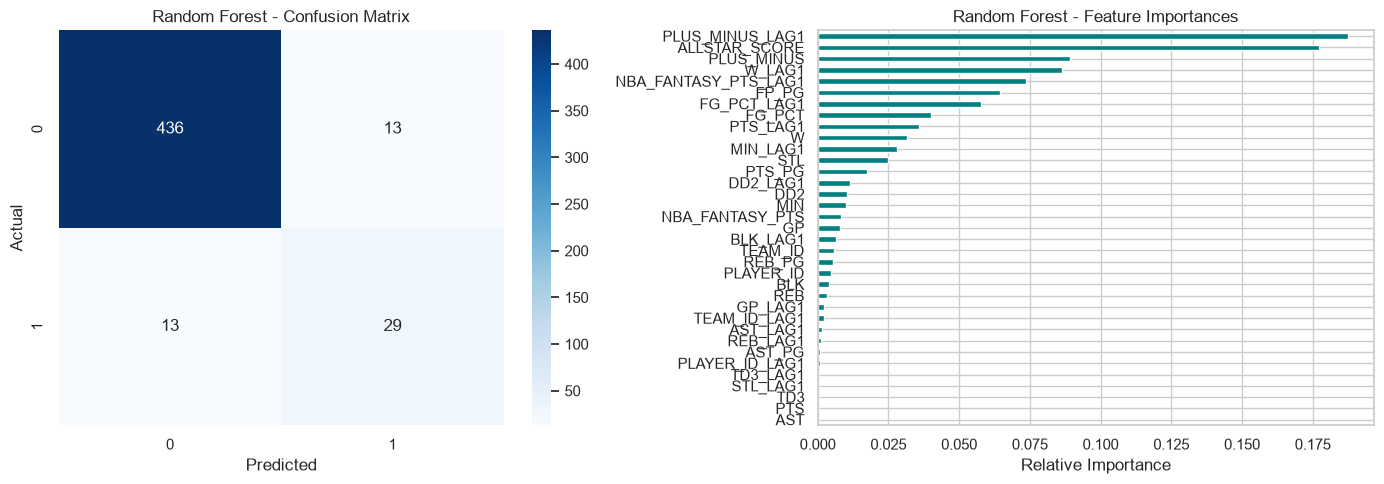

In [182]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix for Random Forest
cm = confusion_matrix(y_test, results['Random Forest']['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Random Forest - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Feature Importances for Random Forest
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.plot(kind='barh', ax=axes[1], color='teal')
axes[1].set_title('Random Forest - Feature Importances')
axes[1].set_xlabel('Relative Importance')

plt.tight_layout()
plt.show()